# Árbol de decisión y comparación con regresión logística

## Objetivos de la sesión

En esta sesión se busca:

1. Retomar el problema de predicción de incumplimiento de pago.
2. Entrenar un modelo de **árbol de decisión**.
3. Compararlo con la **regresión logística** vista en sesiones anteriores.
4. Evaluar ambos modelos con métricas comparables.
5. Analizar ventajas y limitaciones de un modelo lineal frente a uno no lineal.

## Contexto

La regresión logística proporciona un baseline interpretable para clasificación binaria. Sin embargo, este modelo supone una relación relativamente estructurada entre las variables predictoras y la probabilidad de incumplimiento.

Un árbol de decisión permite capturar relaciones no lineales e interacciones entre variables, lo que puede ser útil en problemas donde el riesgo depende de combinaciones más complejas de factores. En esta sesión se compararán ambos enfoques sobre el mismo conjunto de datos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [3]:
df = pd.read_csv("default_credit_clean.csv")

if "default payment next month" in df.columns:
    df = df.rename(columns={"default payment next month": "default_next_month"})

if "AGE_GROUP" not in df.columns:
    bins = [20, 30, 40, 50, 60, 80]
    labels = ["20-29", "30-39", "40-49", "50-59", "60+"]
    df["AGE_GROUP"] = pd.cut(df["AGE"], bins=bins, labels=labels, right=False)

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras columnas:")
print(df.columns.tolist()[:10])
df.head()

Dimensiones del dataset: (30000, 29)

Primeras columnas:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,SEX_LABEL,EDUCATION_LABEL,MARRIAGE_LABEL,AGE_GROUP
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Femenino,Universidad,Casado,20-29
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Femenino,Universidad,Soltero,20-29
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Femenino,Universidad,Soltero,30-39
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Femenino,Universidad,Casado,30-39
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Masculino,Universidad,Casado,50-59


## Separación de predictores y variable objetivo

En esta sección se define:

- `X`: conjunto de variables predictoras,
- `y`: variable objetivo `default_next_month`.

También se eliminan columnas que no deben entrar al modelo, como el identificador `ID` y las etiquetas auxiliares de texto.

In [5]:
cols_to_drop = ["default_next_month"]
optional_drop = ["ID", "SEX_LABEL", "EDUCATION_LABEL", "MARRIAGE_LABEL"]

for col in optional_drop:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df["default_next_month"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("\nColumnas de X:")
print(X.columns.tolist())

Dimensiones de X: (30000, 24)
Dimensiones de y: (30000,)

Columnas de X:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AGE_GROUP']




La matriz de predictores `X` quedó formada por **24 variables**, mientras que la variable objetivo `y` contiene los **30,000** valores de `default_next_month`.

Las variables predictoras incluyen:

- información demográfica: `LIMIT_BAL`, `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`,
- historial de pagos: `PAY_0`, `PAY_2`, ..., `PAY_6`,
- montos facturados: `BILL_AMT1`, ..., `BILL_AMT6`,
- montos pagados: `PAY_AMT1`, ..., `PAY_AMT6`,
- y la variable categórica `AGE_GROUP`.

Se eliminaron correctamente:

- `default_next_month`, por ser la respuesta del modelo,
- `ID`, por ser sólo un identificador,
- y las columnas auxiliares de texto, que son útiles para interpretación pero no deben entrar directamente al entrenamiento.

Con esto ya se tiene definida la estructura básica del problema de clasificación para comparar ambos modelos.

## División en entrenamiento y prueba

Para comparar de forma justa la regresión logística y el árbol de decisión, se utilizará la misma partición en entrenamiento y prueba.

La partición será:

- **80%** para entrenamiento,
- **20%** para prueba,

y además será **estratificada**, para conservar aproximadamente la misma proporción de incumplimiento en ambos subconjuntos.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nProporción de incumplimiento en y_train:", y_train.mean())
print("Proporción de incumplimiento en y_test :", y_test.mean())

X_train: (24000, 24)
X_test : (6000, 24)
y_train: (24000,)
y_test : (6000,)

Proporción de incumplimiento en y_train: 0.22120833333333334
Proporción de incumplimiento en y_test : 0.22116666666666668




La partición se realizó correctamente:

- **24,000 observaciones** quedaron en el conjunto de entrenamiento,
- **6,000 observaciones** quedaron en el conjunto de prueba.

Además, la proporción de incumplimiento se conservó prácticamente igual en ambos subconjuntos:

- en `y_train`: aproximadamente **22.12%**,
- en `y_test`: aproximadamente **22.12%**.

Esto confirma que la partición **estratificada** funcionó correctamente. Usar la misma división para ambos modelos es importante, ya que permite una comparación más justa entre la regresión logística y el árbol de decisión.

## Identificación de variables numéricas y categóricas

Antes de entrenar los modelos, se distinguen las variables que serán tratadas como:

- **categóricas**, usando codificación `one-hot`,
- **numéricas**, usando imputación y, en el caso de la regresión logística, escalamiento.

Las variables categóricas consideradas serán:

- `SEX`
- `EDUCATION`
- `MARRIAGE`
- `AGE_GROUP`

El resto se tratará como variables numéricas.

In [7]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"]
categorical_features = [col for col in categorical_features if col in X_train.columns]

numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Variables categóricas:")
print(categorical_features)

print("\nNúmero de variables categóricas:", len(categorical_features))

print("\nVariables numéricas:")
print(numeric_features)

print("\nNúmero de variables numéricas:", len(numeric_features))

Variables categóricas:
['SEX', 'EDUCATION', 'MARRIAGE', 'AGE_GROUP']

Número de variables categóricas: 4

Variables numéricas:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Número de variables numéricas: 20


## Preprocesamiento para la regresión logística

La regresión logística requiere un tratamiento más cuidadoso de la escala de las variables numéricas. Por ello, se definirá un pipeline con:

- **variables numéricas**:
  - imputación por mediana,
  - escalamiento estandarizado;

- **variables categóricas**:
  - imputación por la categoría más frecuente,
  - codificación `one-hot`.

Este preprocesamiento será usado únicamente para la regresión logística.

In [8]:
numeric_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lr, numeric_features),
        ("cat", categorical_transformer_lr, categorical_features)
    ]
)

print(preprocessor_lr)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
                                  'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
                                  'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
                                  'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                                  'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                                  'PAY_AMT5', 'PAY_AMT6']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  



El `ColumnTransformer` para la regresión logística se definió correctamente y muestra dos rutas de transformación:

### Variables numéricas
Se aplicará un pipeline con:

1. **Imputación por mediana**, para manejar posibles valores faltantes.
2. **Escalamiento estandarizado**, para que las variables numéricas queden en una escala comparable.

Este escalamiento es importante porque la regresión logística es sensible a diferencias grandes de magnitud entre variables como `LIMIT_BAL`, `BILL_AMT*` y `PAY_AMT*`.

### Variables categóricas
Se aplicará un segundo pipeline con:

1. **Imputación por la categoría más frecuente**,
2. **Codificación one-hot**, eliminando la primera categoría para evitar redundancia.

Con esto, la regresión logística recibirá una representación adecuada de los datos, respetando la naturaleza numérica o categórica de cada predictor.

## Preprocesamiento para el árbol de decisión

A diferencia de la regresión logística, un árbol de decisión no requiere que las variables numéricas estén escaladas. Sin embargo, sí conviene:

- imputar valores faltantes,
- y codificar las variables categóricas.

Por ello, se construirá un pipeline específico para el árbol, sin incluir `StandardScaler`.

In [9]:
numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer_tree, categorical_features)
    ]
)

print(preprocessor_tree)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
                                  'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
                                  'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
                                  'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                                  'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                                  'PAY_AMT5', 'PAY_AMT6']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                   



El `ColumnTransformer` para el árbol de decisión se definió correctamente. Su estructura es similar a la de la regresión logística, pero con una diferencia importante:

### Variables numéricas
Se aplicará únicamente:

- **imputación por mediana**.

No se incluye escalamiento porque los árboles de decisión no dependen de la magnitud relativa de las variables de la misma manera que los modelos lineales. En otras palabras, un árbol decide mediante particiones y umbrales, por lo que no necesita variables estandarizadas para funcionar adecuadamente.

### Variables categóricas
Se aplicará:

- **imputación por la categoría más frecuente**,
- y **codificación one-hot**.

Esto garantiza que el árbol reciba entradas limpias y bien representadas, respetando la naturaleza categórica de variables como `SEX`, `EDUCATION`, `MARRIAGE` y `AGE_GROUP`.

Con esto, ya están listos los pipelines de preprocesamiento específicos para cada modelo.

## Entrenamiento de la regresión logística

Primero se reconstruirá la regresión logística como modelo baseline, usando el pipeline de preprocesamiento definido para este caso.

Esto permitirá compararla directamente con el árbol de decisión sobre el mismo conjunto de prueba.

In [10]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

log_reg.fit(X_train, y_train)

print("Regresión logística entrenada correctamente.")

Regresión logística entrenada correctamente.



La regresión logística se entrenó correctamente usando el pipeline de preprocesamiento definido para este modelo.

Esto garantiza que:

- las variables numéricas fueron imputadas y escaladas,
- las variables categóricas fueron imputadas y codificadas,
- y el ajuste del modelo se realizó sobre el conjunto de entrenamiento.

Con esto ya se cuenta con el **modelo baseline** listo para comparación. El siguiente paso será entrenar el **árbol de decisión** usando su propio pipeline de preprocesamiento.

## Entrenamiento del árbol de decisión

Ahora se entrenará un modelo de **árbol de decisión** utilizando el pipeline de preprocesamiento específico para este tipo de modelo.

En esta primera versión se usará un árbol con parámetros por defecto, de modo que sirva como punto de partida para la comparación inicial con la regresión logística.

In [11]:
tree_clf = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_clf.fit(X_train, y_train)

print("Árbol de decisión entrenado correctamente.")

Árbol de decisión entrenado correctamente.




El árbol de decisión se entrenó correctamente usando el pipeline de preprocesamiento diseñado para este modelo.

A diferencia de la regresión logística, aquí no fue necesario escalar las variables numéricas. El árbol trabaja mediante particiones sucesivas del espacio de predictores, por lo que su lógica de aprendizaje se basa en reglas y umbrales, no en combinaciones lineales de variables escaladas.

Con esto ya se tienen disponibles los dos modelos que se desean comparar en esta sesión:

- **Regresión logística** como baseline lineal,
- **Árbol de decisión** como modelo no lineal.

## Predicciones y probabilidades de ambos modelos

Para comparar adecuadamente los dos enfoques, se obtendrán:

- predicciones de clase,
- y probabilidades estimadas de incumplimiento,

tanto para la regresión logística como para el árbol de decisión, usando el conjunto de prueba.

In [12]:
# Regresión logística
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# Árbol de decisión
y_pred_tree = tree_clf.predict(X_test)
y_proba_tree = tree_clf.predict_proba(X_test)[:, 1]

print("Primeras 10 predicciones de regresión logística:")
print(y_pred_lr[:10])

print("\nPrimeras 10 probabilidades de regresión logística:")
print(y_proba_lr[:10])

print("\nPrimeras 10 predicciones del árbol de decisión:")
print(y_pred_tree[:10])

print("\nPrimeras 10 probabilidades del árbol de decisión:")
print(y_proba_tree[:10])

Primeras 10 predicciones de regresión logística:
[0 0 0 0 0 0 0 0 0 0]

Primeras 10 probabilidades de regresión logística:
[0.10806998 0.11724991 0.2223453  0.09658985 0.02977732 0.21014218
 0.13061203 0.15772985 0.0784884  0.19577078]

Primeras 10 predicciones del árbol de decisión:
[0 0 0 0 0 1 0 0 1 0]

Primeras 10 probabilidades del árbol de decisión:
[0. 0. 0. 0. 0. 1. 0. 0. 1. 0.]




Las primeras observaciones muestran una diferencia interesante entre ambos modelos:

### Regresión logística
- En los primeros 10 casos, todas las predicciones son `0 = no incumplimiento`.
- Las probabilidades estimadas son valores continuos entre 0 y 1, en este caso relativamente bajos.

Esto es consistente con la naturaleza probabilística de la regresión logística: el modelo produce una estimación suave del riesgo y luego la convierte en clase usando un umbral.

### Árbol de decisión
- En los primeros 10 casos ya aparecen algunas predicciones positivas (`1 = incumplimiento`).
- Las probabilidades estimadas observadas son extremas, en este caso `0` o `1`.

Esto refleja una característica típica de los árboles de decisión sin calibración: tienden a generar probabilidades más bruscas o extremas, porque la estimación depende de la proporción de clases dentro de las hojas terminales.

En conjunto, esta comparación inicial sugiere que ambos modelos no sólo pueden diferir en sus predicciones, sino también en la forma en que representan la incertidumbre. La regresión logística produce probabilidades más graduales, mientras que el árbol de decisión puede comportarse de manera más tajante.

## Función auxiliar para evaluar modelos

Para comparar la regresión logística y el árbol de decisión con el mismo criterio, se define una función que calcule las métricas principales de clasificación:

- `accuracy`
- `precision`
- `recall`
- `F1-score`
- `ROC-AUC`

Estas métricas se calcularán sobre el conjunto de prueba.

In [13]:
def evaluar_modelo(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }

resultados_modelos = pd.DataFrame({
    "Logistic Regression": evaluar_modelo(y_test, y_pred_lr, y_proba_lr),
    "Decision Tree": evaluar_modelo(y_test, y_pred_tree, y_proba_tree)
})

resultados_modelos

,Logistic Regression,Decision Tree
accuracy,0.8085,0.7162
precision,0.6894,0.3672
recall,0.2442,0.3919
f1,0.3606,0.3791
roc_auc,0.7102,0.6005




La tabla comparativa muestra diferencias claras entre la **regresión logística** y el **árbol de decisión** en el conjunto de prueba.

### Regresión logística
- **Accuracy = 0.8085**
- **Precision = 0.6894**
- **Recall = 0.2442**
- **F1 = 0.3606**
- **ROC-AUC = 0.7102**

La regresión logística mantiene un comportamiento **más conservador**: logra una precisión relativamente alta, pero detecta sólo una fracción reducida de los incumplimientos reales.

### Árbol de decisión
- **Accuracy = 0.7162**
- **Precision = 0.3672**
- **Recall = 0.3919**
- **F1 = 0.3791**
- **ROC-AUC = 0.6005**

El árbol de decisión detecta una proporción mayor de incumplimientos que la regresión logística, como lo muestra su `recall` más alto. Sin embargo, lo hace a costa de una caída importante en `precision`, `accuracy` y `ROC-AUC`.

### Interpretación comparativa
En esta primera comparación:

- la **regresión logística** ofrece mejor capacidad discriminante global (`ROC-AUC`) y mejores predicciones positivas en términos de `precision`,
- mientras que el **árbol de decisión** logra captar más incumplimientos reales (`recall`), aunque con más errores y menor estabilidad general.

Esto sugiere que, en su versión actual, el árbol de decisión está siendo más agresivo al clasificar incumplimiento, pero con un costo importante en falsas alarmas y pérdida de desempeño global. También puede ser una señal de que el árbol, tal como está, necesita control de complejidad para evitar sobreajuste.

## Matrices de confusión

Para profundizar en la comparación entre modelos, se construirán las matrices de confusión de:

- la regresión logística,
- y el árbol de decisión.

Esto permitirá observar con más detalle cómo se distribuyen los aciertos y errores de cada clasificador.

In [17]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_tree = confusion_matrix(y_test, y_pred_tree)

cm_lr_df = pd.DataFrame(
    cm_lr,
    index=["Real: No default", "Real: Default"],
    columns=["Pred: No default", "Pred: Default"]
)

cm_tree_df = pd.DataFrame(
    cm_tree,
    index=["Real: No default", "Real: Default"],
    columns=["Pred: No default", "Pred: Default"]
)

print("Matriz de confusión - Regresión logística")
display(cm_lr_df)

print("Matriz de confusión - Árbol de decisión")
display(cm_tree_df)

Matriz de confusión - Regresión logística


,Pred: No default,Pred: Default
Real: No default,4527,146
Real: Default,1003,324


Matriz de confusión - Árbol de decisión


,Pred: No default,Pred: Default
Real: No default,3777,896
Real: Default,807,520




Las matrices de confusión permiten comparar con más detalle cómo se comporta cada modelo.

### Regresión logística
- **Verdaderos negativos:** 4527
- **Falsos positivos:** 146
- **Falsos negativos:** 1003
- **Verdaderos positivos:** 324

La regresión logística clasifica muy bien a la clase mayoritaria (`No default`) y comete pocos falsos positivos. Sin embargo, deja escapar muchos incumplimientos reales, como se refleja en el número elevado de falsos negativos.

### Árbol de decisión
- **Verdaderos negativos:** 3777
- **Falsos positivos:** 896
- **Falsos negativos:** 807
- **Verdaderos positivos:** 520

El árbol de decisión identifica más clientes que sí incumplen, lo que se traduce en más verdaderos positivos y menos falsos negativos que la regresión logística. No obstante, esto ocurre a costa de un aumento muy fuerte en los falsos positivos.

### Comparación
En términos prácticos:

- la **regresión logística** es más conservadora y protege mejor contra falsas alarmas,
- mientras que el **árbol de decisión** detecta más incumplimientos, pero también marca como riesgosos a muchos clientes que en realidad no incumplen.

Esto ilustra claramente el compromiso entre distintos tipos de error y ayuda a entender por qué un modelo con mayor `recall` no necesariamente es mejor en todos los sentidos.

## Visualización de las matrices de confusión

Para complementar la comparación, se representarán ambas matrices de confusión mediante mapas de calor. Esto permitirá apreciar visualmente las diferencias entre los dos modelos.

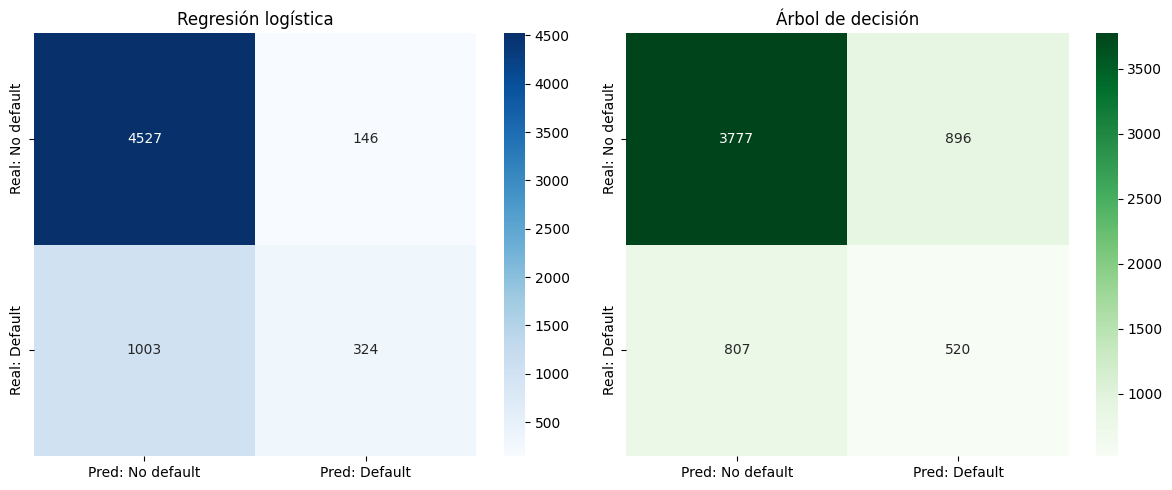

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_lr_df, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Regresión logística")

sns.heatmap(cm_tree_df, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Árbol de decisión")

plt.tight_layout()
plt.show()



La comparación visual entre ambas matrices de confusión refuerza las diferencias observadas en la tabla numérica.

### Regresión logística
El mapa de calor muestra una concentración muy fuerte en la celda de **verdaderos negativos**, junto con una celda pequeña de **falsos positivos**. Esto confirma que la regresión logística es bastante conservadora: clasifica correctamente a muchos clientes sin incumplimiento, pero detecta relativamente pocos casos positivos.

### Árbol de decisión
En el árbol de decisión se observa una celda de **verdaderos positivos** más grande que en la regresión logística, lo que indica una mejor detección de incumplimientos. Sin embargo, también aparece una celda mucho mayor de **falsos positivos**, lo que refleja un incremento importante en falsas alarmas.

### Comparación general
Visualmente, se aprecia que:

- la **regresión logística** favorece más la estabilidad y la precisión,
- mientras que el **árbol de decisión** favorece más la detección de positivos, pero con menor control sobre los errores en la clase negativa.

Esto ayuda a entender que ambos modelos responden de manera distinta al mismo problema y que la elección entre ellos depende del tipo de error que se quiera priorizar.

## Curvas ROC de ambos modelos

Para comparar la capacidad discriminante global de la regresión logística y del árbol de decisión, se construirán sus curvas ROC en la misma gráfica.

Esto permitirá observar cuál de los dos modelos separa mejor a los clientes con y sin incumplimiento a lo largo de distintos umbrales.

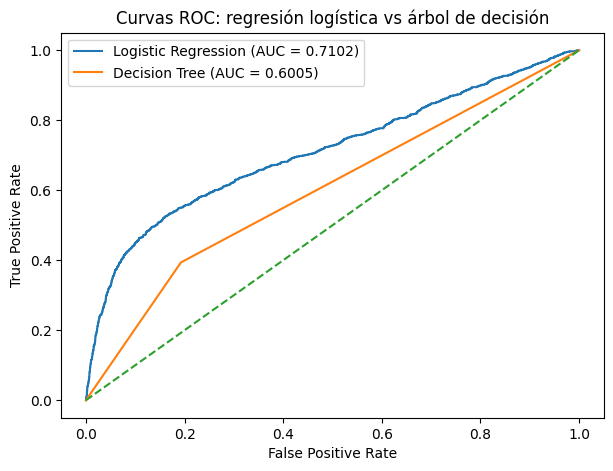

In [19]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree)

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_tree = roc_auc_score(y_test, y_proba_tree)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.4f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC: regresión logística vs árbol de decisión")
plt.legend()
plt.show()



La comparación de las curvas ROC muestra de manera clara que la **regresión logística** supera al **árbol de decisión** en capacidad discriminante global.

En particular:

- la regresión logística alcanza un **AUC = 0.7102**,
- mientras que el árbol de decisión obtiene un **AUC = 0.6005**.

La curva de la regresión logística se mantiene más alejada de la diagonal de referencia, lo que indica que distingue mejor entre clientes con y sin incumplimiento a lo largo de distintos umbrales. En cambio, la curva del árbol de decisión está más cercana a la línea base, lo que sugiere un desempeño bastante más limitado.

Esto confirma que, aunque el árbol de decisión logró mayor `recall` en la comparación anterior, su capacidad general para ordenar correctamente a los clientes según su riesgo es menor que la de la regresión logística. Por ello, en esta primera versión, la regresión logística parece ser el modelo más sólido de los dos.

## Importancia de variables en el árbol de decisión

Una ventaja del árbol de decisión es que permite obtener una medida de **importancia de variables**, la cual indica qué predictores contribuyen más a las particiones del modelo.

En esta sección se identificarán las variables más relevantes según el árbol entrenado.

In [20]:
# Obtener nombres de variables transformadas
feature_names_num = numeric_features

ohe_tree = tree_clf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat = ohe_tree.get_feature_names_out(categorical_features)

feature_names_tree = np.concatenate([feature_names_num, feature_names_cat])

importances = tree_clf.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names_tree,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
2,PAY_0,0.1614
8,BILL_AMT1,0.0692
1,AGE,0.0638
0,LIMIT_BAL,0.0607
16,PAY_AMT3,0.0572
19,PAY_AMT6,0.0493
9,BILL_AMT2,0.0473
12,BILL_AMT5,0.0465
15,PAY_AMT2,0.0459
13,BILL_AMT6,0.0451




Las variables más importantes para el árbol de decisión muestran que el modelo está apoyándose principalmente en información relacionada con el **historial reciente de pago** y en variables financieras de monto.

La variable con mayor importancia es:

- **`PAY_0`**, con una importancia de **0.1614**.

Esto es consistente con el análisis exploratorio realizado en sesiones anteriores: el estado de pago más reciente es una de las señales más fuertes para anticipar incumplimiento futuro.

Después aparecen variables como:

- `BILL_AMT1`,
- `AGE`,
- `LIMIT_BAL`,
- `PAY_AMT3`,
- `PAY_AMT6`,
- `BILL_AMT2`,
- y otros montos facturados o pagados.

En conjunto, esto sugiere que el árbol de decisión está construyendo sus reglas principalmente a partir de:

1. el **historial de mora reciente**,
2. el **nivel de endeudamiento reflejado en facturación**,
3. el **comportamiento de pago**,
4. y algunas variables demográficas o de capacidad financiera, como `AGE` y `LIMIT_BAL`.

También es notable que entre las variables más importantes no aparecen, al menos en este primer bloque, muchas de las categorías derivadas de `SEX`, `EDUCATION`, `MARRIAGE` o `AGE_GROUP`, lo que indica que el árbol está encontrando más señal predictiva en las variables financieras y de pago que en las variables demográficas codificadas.

## Visualización de las variables más importantes

Para facilitar la interpretación, se representarán en una gráfica de barras las variables con mayor importancia en el árbol de decisión.

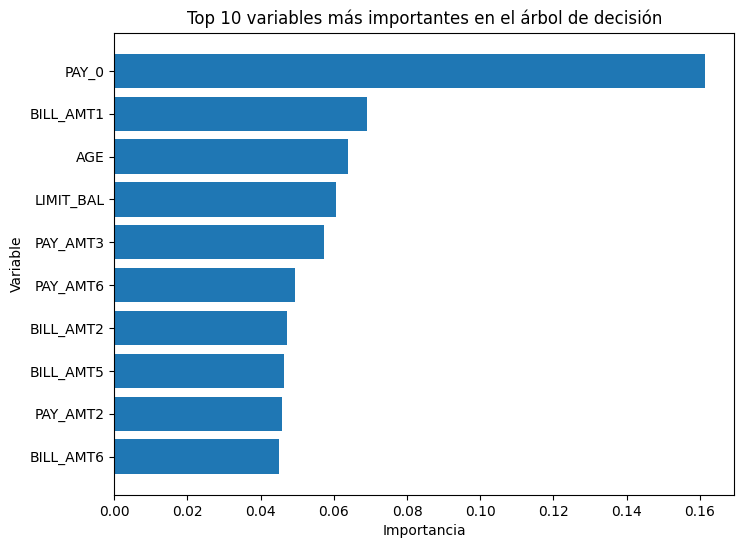

In [22]:
top_n = 10
top_features = importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 10 variables más importantes en el árbol de decisión")
plt.show()



La gráfica de barras confirma de manera visual que **`PAY_0`** es, con diferencia, la variable más influyente en el árbol de decisión. Esto refuerza la idea de que el **historial de pago más reciente** es una señal central para anticipar incumplimiento.

Después de `PAY_0`, aparecen variables relacionadas con:

- el **nivel de deuda reciente**, como `BILL_AMT1`,
- características del cliente, como `AGE` y `LIMIT_BAL`,
- y distintos montos de pago o facturación (`PAY_AMT*`, `BILL_AMT*`).

La distribución de importancias sugiere que el árbol está basando sus reglas principalmente en una combinación de:

1. **comportamiento reciente de pago**,
2. **montos adeudados**,
3. **montos pagados**,
4. y algunas características personales o financieras generales.

En términos sustantivos, esto es razonable: un cliente con atraso reciente, ciertos niveles de facturación y ciertos patrones de pago puede presentar un mayor riesgo de incumplimiento. Sin embargo, aunque estas importancias ayudan a interpretar el modelo, no deben leerse como relaciones causales, sino como indicadores de utilidad predictiva dentro del árbol entrenado.

## Conclusiones 

En esta sesión se compararon dos modelos de clasificación para predecir incumplimiento de pago:

- **regresión logística**,
- **árbol de decisión**.

Los principales hallazgos fueron:

1. La **regresión logística** obtuvo mejor desempeño global en:
   - `accuracy`,
   - `precision`,
   - y `ROC-AUC`.

2. El **árbol de decisión** logró un `recall` mayor, es decir, detectó más casos reales de incumplimiento.

3. Sin embargo, ese aumento en `recall` vino acompañado de:
   - más falsos positivos,
   - menor `accuracy`,
   - y una capacidad discriminante global más baja.

4. La comparación de curvas ROC mostró que la regresión logística separa mejor a los clientes con y sin incumplimiento en esta primera versión del análisis.

5. El análisis de importancia de variables indicó que `PAY_0` es el predictor más relevante dentro del árbol, seguido por variables relacionadas con montos facturados, pagos anteriores, edad y límite de crédito.

En conjunto, esta sesión muestra que un modelo más flexible no necesariamente produce mejores resultados. En este caso, la **regresión logística** se mantiene como una referencia más sólida, mientras que el **árbol de decisión** aporta una perspectiva útil sobre relaciones no lineales y reglas de decisión, aunque con señales de menor estabilidad en su forma actual.



## Tarea 

Con base en los resultados obtenidos, responder lo siguiente:

1. Comparar en una tabla las métricas de la regresión logística y del árbol de decisión:
   - accuracy,
   - precision,
   - recall,
   - F1-score,
   - ROC-AUC.

2. Redactar un párrafo donde expliques:
   - en qué métrica fue mejor la regresión logística,
   - en qué métrica fue mejor el árbol de decisión,
   - y qué implican esas diferencias.

3. Revisar las matrices de confusión y responder:
   - ¿qué modelo comete más falsos positivos?
   - ¿qué modelo comete más falsos negativos?
   - ¿cuál sería preferible si el objetivo principal es detectar más incumplimientos?

4. Escribir una breve interpretación de las variables más importantes del árbol de decisión.

